In [1]:
target_accessions = [
    "P13674",  # P4HA1
    "O15460",  # P4HA2
    "Q7Z4N8",  # P4HA3
    "P07237",  # P4HB
    "Q02809",  # PLOD1
    "O00469",  # PLOD2
    "O60568",  # PLOD3
]   

print(("Number of proteins:"), len(target_accessions))

Number of proteins: 7


In [2]:
import requests 

accession = target_accessions[0]

url = f"https://rest.uniprot.org/uniprotkb/{accession}.json"

response = requests.get(url, timeout=30)

print("HTTP status:", response.status_code)

response.raise_for_status()
record = response.json()

HTTP status: 200


In [3]:
p4ha1_api = {
    "uniprot_id": record["primaryAccession"],
    "gene_symbol": record["genes"][0]["geneName"]["value"],
    "protein_name": record["proteinDescription"]["recommendedName"]["fullName"]["value"],
    "organism": record["organism"]["scientificName"],
    "taxonomy_id": record["organism"]["taxonId"],
    "review_status": record["entryType"],
    "sequence_length": record["sequence"]["length"],
  
}

p4ha1_api

{'uniprot_id': 'P13674',
 'gene_symbol': 'P4HA1',
 'protein_name': 'Prolyl 4-hydroxylase subunit alpha-1',
 'organism': 'Homo sapiens',
 'taxonomy_id': 9606,
 'review_status': 'UniProtKB reviewed (Swiss-Prot)',
 'sequence_length': 534}

In [4]:
assert p4ha1_api["uniprot_id"] == "P13674"
assert p4ha1_api["gene_symbol"] == "P4HA1"
assert p4ha1_api["organism"] == "Homo sapiens"
assert p4ha1_api["taxonomy_id"] == 9606
assert p4ha1_api["review_status"].startswith("UniProtKB reviewed")
assert p4ha1_api["sequence_length"] == 534

print("P4HA1 validation passed.")

P4HA1 validation passed.


In [5]:
from datetime import date

def extract_subcellular_location(record):
    locations = []

    for comment in record.get("comments", []):
        if comment.get("commentType") != "SUBCELLULAR LOCATION":
            continue

        for location_entry in comment.get(
            "subcellularLocations", []
        ):
            location = (
                location_entry
                .get("location", {})
                .get("value")
            )

            if location and location not in locations:
                locations.append(location)

    if locations:
        return "; ".join(locations)
    
    return None

def fetch_uniprot_record(accession):
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.json"

    response = requests.get(url, timeout = 30)
    response.raise_for_status()

    record = response.json()

    protein_record = {
        "uniprot_id": record["primaryAccession"],
        "gene_symbol": record["genes"][0]["geneName"]["value"],
        "protein_name": (
            record["proteinDescription"]
            ["recommendedName"]
            ["fullName"]
            ["value"]
        ),
        "organism": record["organism"]["scientificName"],
        "taxonomy_id": record["organism"]["taxonId"],
        "review_status":( 
            "reviewed"
            if record["entryType"].startswith("UniProtKB reviewed")
            else "unreviewed"
        ),
        "sequence_length": record["sequence"]["length"],
        "subcellular_location": (
         extract_subcellular_location(record)
        ),
        "source_url":(
            f"https://www.uniprot.org/uniprotkb/{accession}/entry"
        ),
        "retrieved_at": date.today().isoformat(),
    }


    return protein_record
    

In [6]:
test_record = fetch_uniprot_record("P13674")

test_record

{'uniprot_id': 'P13674',
 'gene_symbol': 'P4HA1',
 'protein_name': 'Prolyl 4-hydroxylase subunit alpha-1',
 'organism': 'Homo sapiens',
 'taxonomy_id': 9606,
 'review_status': 'reviewed',
 'sequence_length': 534,
 'subcellular_location': 'Endoplasmic reticulum lumen',
 'source_url': 'https://www.uniprot.org/uniprotkb/P13674/entry',
 'retrieved_at': '2026-07-28'}

In [7]:
protein_records = []

for target_accession in target_accessions:
    protein_record = fetch_uniprot_record(target_accession)
    protein_records.append(protein_record)

    print(
        f"Retrieved {protein_record['gene_symbol']}"
        f"({protein_record['uniprot_id']})"
    )

print   ("Total records retrieved:", len(protein_records))

Retrieved P4HA1(P13674)
Retrieved P4HA2(O15460)
Retrieved P4HA3(Q7Z4N8)
Retrieved P4HB(P07237)
Retrieved PLOD1(Q02809)
Retrieved PLOD2(O00469)
Retrieved PLOD3(O60568)
Total records retrieved: 7


In [8]:
retrieved_accessions = [
    protein["uniprot_id"]for protein in protein_records
]

assert len(protein_records) == 7
assert retrieved_accessions == target_accessions
assert all(
    protein["taxonomy_id"] == 9606
    for protein in protein_records
)
assert all(
    protein["review_status"].startswith("reviewed")
    for protein in protein_records
)

print("Batch validation passed: Seven human proteins.")

Batch validation passed: Seven human proteins.


In [9]:
import pandas as pd

proteins_df = pd.DataFrame(protein_records)

proteins_df

,uniprot_id,gene_symbol,protein_name,organism,taxonomy_id,review_status,sequence_length,subcellular_location,source_url,retrieved_at
0,P13674,P4HA1,Prolyl 4-hydroxylase subunit alpha-1,Homo sapiens,9606,reviewed,534,Endoplasmic reticulum lumen,https://www.uniprot.org/uniprotkb/P13674/entry,2026-07-28
1,O15460,P4HA2,Prolyl 4-hydroxylase subunit alpha-2,Homo sapiens,9606,reviewed,535,Endoplasmic reticulum lumen,https://www.uniprot.org/uniprotkb/O15460/entry,2026-07-28
2,Q7Z4N8,P4HA3,Prolyl 4-hydroxylase subunit alpha-3,Homo sapiens,9606,reviewed,544,Endoplasmic reticulum lumen,https://www.uniprot.org/uniprotkb/Q7Z4N8/entry,2026-07-28
3,P07237,P4HB,Protein disulfide-isomerase,Homo sapiens,9606,reviewed,508,Endoplasmic reticulum; Endoplasmic reticulum l...,https://www.uniprot.org/uniprotkb/P07237/entry,2026-07-28
4,Q02809,PLOD1,"Procollagen-lysine,2-oxoglutarate 5-dioxygenase 1",Homo sapiens,9606,reviewed,727,Rough endoplasmic reticulum membrane,https://www.uniprot.org/uniprotkb/Q02809/entry,2026-07-28
5,O00469,PLOD2,"Procollagen-lysine,2-oxoglutarate 5-dioxygenase 2",Homo sapiens,9606,reviewed,737,Rough endoplasmic reticulum membrane; Cytoplasm,https://www.uniprot.org/uniprotkb/O00469/entry,2026-07-28
6,O60568,PLOD3,Multifunctional procollagen lysine hydroxylase...,Homo sapiens,9606,reviewed,738,Rough endoplasmic reticulum; Endoplasmic retic...,https://www.uniprot.org/uniprotkb/O60568/entry,2026-07-28


In [10]:
role_by_gene = {
    "P4HA1": "Catalytic alpha subunit for collagen Proline 4-hydroxylation",
    "P4HA2": "Catalytic alpha subunit for collagen Proline 4-hydroxylation",
    "P4HA3": "Catalytic alpha subunit for collagen Proline 4-hydroxylation",
    "P4HB": "Supporting beta subunit for collagen Prolyl 4-hydroxylase",
    "PLOD1": "Catalyzes collagen Lysine hydroxylation",
    "PLOD2": "Catalyzes collagen Lysine hydroxylation",
    "PLOD3": "Catalyzes collagen Lysine hydroxylation",
}



proteins_df["role_in_mechanism"] = (
    proteins_df["gene_symbol"].map(role_by_gene)
   
)
proteins_df[
    ["gene_symbol", "role_in_mechanism"]
]
column_order = [
    "uniprot_id",
    "gene_symbol",
    "protein_name",
    "role_in_mechanism",
    "organism",
    "taxonomy_id",
    "review_status",
    "sequence_length",
    "subcellular_location",
    "source_url",
    "retrieved_at",
]

proteins_df = proteins_df[column_order]

proteins_df





,uniprot_id,gene_symbol,protein_name,role_in_mechanism,organism,taxonomy_id,review_status,sequence_length,subcellular_location,source_url,retrieved_at
0,P13674,P4HA1,Prolyl 4-hydroxylase subunit alpha-1,Catalytic alpha subunit for collagen Proline 4...,Homo sapiens,9606,reviewed,534,Endoplasmic reticulum lumen,https://www.uniprot.org/uniprotkb/P13674/entry,2026-07-28
1,O15460,P4HA2,Prolyl 4-hydroxylase subunit alpha-2,Catalytic alpha subunit for collagen Proline 4...,Homo sapiens,9606,reviewed,535,Endoplasmic reticulum lumen,https://www.uniprot.org/uniprotkb/O15460/entry,2026-07-28
2,Q7Z4N8,P4HA3,Prolyl 4-hydroxylase subunit alpha-3,Catalytic alpha subunit for collagen Proline 4...,Homo sapiens,9606,reviewed,544,Endoplasmic reticulum lumen,https://www.uniprot.org/uniprotkb/Q7Z4N8/entry,2026-07-28
3,P07237,P4HB,Protein disulfide-isomerase,Supporting beta subunit for collagen Prolyl 4-...,Homo sapiens,9606,reviewed,508,Endoplasmic reticulum; Endoplasmic reticulum l...,https://www.uniprot.org/uniprotkb/P07237/entry,2026-07-28
4,Q02809,PLOD1,"Procollagen-lysine,2-oxoglutarate 5-dioxygenase 1",Catalyzes collagen Lysine hydroxylation,Homo sapiens,9606,reviewed,727,Rough endoplasmic reticulum membrane,https://www.uniprot.org/uniprotkb/Q02809/entry,2026-07-28
5,O00469,PLOD2,"Procollagen-lysine,2-oxoglutarate 5-dioxygenase 2",Catalyzes collagen Lysine hydroxylation,Homo sapiens,9606,reviewed,737,Rough endoplasmic reticulum membrane; Cytoplasm,https://www.uniprot.org/uniprotkb/O00469/entry,2026-07-28
6,O60568,PLOD3,Multifunctional procollagen lysine hydroxylase...,Catalyzes collagen Lysine hydroxylation,Homo sapiens,9606,reviewed,738,Rough endoplasmic reticulum; Endoplasmic retic...,https://www.uniprot.org/uniprotkb/O60568/entry,2026-07-28


In [11]:
def extract_subcellular_location(record):
    locations = []

    for comment in record.get("comments", []):
        if comment.get("commentType") != "SUBCELLULAR LOCATION":
            continue

        for location_entry in comment.get(
                "subcellularLocations", []
                ):
                    location = (
                         location_entry
                         .get("location", {})
                         .get("value")
                    )
                    if location and location not in locations:
                        locations.append(location)
    if  locations:
        return "; ".join(locations)                 
    return None

In [12]:
p4ha1_locations = extract_subcellular_location(record)

print ("P4HA1 subcellular locations:", p4ha1_locations)

P4HA1 subcellular locations: Endoplasmic reticulum lumen


In [13]:
p4ha2_locations = extract_subcellular_location(record)

print ("P4HA2 subcellular locations:", p4ha2_locations)

P4HA2 subcellular locations: Endoplasmic reticulum lumen


In [14]:
manual_df = pd.read_csv("proteins.csv")

manual_ph4a1 = (
    manual_df[
        manual_df["uniprot_id"] == "P13674"
    ]
    .iloc[0]
)

automated_ph4a1 = (
    proteins_df[
        proteins_df["uniprot_id"] == "P13674"
    ]
    .iloc[0]
)

comparison = pd.DataFrame({
    "manual": manual_ph4a1,
    "automated": automated_ph4a1,
})

comparison["match"] = (
    comparison["manual"].astype(str)
      == comparison["automated"].astype(str)
)

comparison

,manual,automated,match
uniprot_id,P13674,P13674,True
gene_symbol,P4HA1,P4HA1,True
protein_name,Prolyl 4-hydroxylase subunit alpha-1,Prolyl 4-hydroxylase subunit alpha-1,True
role_in_mechanism,Catalytic alpha subunit for collagen Proline 4...,Catalytic alpha subunit for collagen Proline 4...,True
organism,Homo sapiens,Homo sapiens,True
taxonomy_id,9606,9606,True
review_status,reviewed,reviewed,True
sequence_length,534,534,True
subcellular_location,Endoplasmic reticulum lumen,Endoplasmic reticulum lumen,True
source_url,https://www.uniprot.org/uniprotkb/P13674/entry,https://www.uniprot.org/uniprotkb/P13674/entry,True


In [15]:
proteins_df.to_csv("proteins.csv", index=False)

print("Saved proteins.csv with", len(proteins_df), "proteins.")

Saved proteins.csv with 7 proteins.


In [16]:
fasta_records = []

for target_accession in target_accessions:
    fasta_url = (
        f"https://rest.uniprot.org/uniprotkb/"
        f"{target_accession}.fasta"
    )

    response = requests.get(fasta_url, timeout=30)
    response.raise_for_status()

    fasta_records.append(response.text.strip())

    print("Retrieved FASTA:", target_accession)

fasta_text = "\n".join(fasta_records) + "\n"   

Retrieved FASTA: P13674
Retrieved FASTA: O15460
Retrieved FASTA: Q7Z4N8
Retrieved FASTA: P07237
Retrieved FASTA: Q02809
Retrieved FASTA: O00469
Retrieved FASTA: O60568


In [17]:
with open("proteins.fasta", "w") as fasta_file:
    fasta_file.write(fasta_text)

print("Saved proteins.fasta")    

Saved proteins.fasta


In [18]:
sequence_count = fasta_text.count(">")

assert sequence_count == len(target_accessions)

print("FASTA contains", sequence_count, "protein sequences")

FASTA contains 7 protein sequences


In [19]:
fasta_lengths = {}

current_accession = None
current_sequence = []

for line in fasta_text.splitlines():
    if line.startswith(">"):
        if current_accession is not None: 
            fasta_lengths[current_accession] = len(
                "".join(current_sequence)
                )
        
        current_accession = line.split("|")[1]
        current_sequence = []
    else:
        current_sequence.append(line.strip())

# Save the final sequence
if current_accession is not None:
    fasta_lengths[current_accession] = len(
        "".join(current_sequence)
    )

In [20]:
proteins_df["fasta_length"] = (
    proteins_df["uniprot_id"].map(fasta_lengths)
)

proteins_df["length_match"] = (
    proteins_df["sequence_length"]
    == proteins_df["fasta_length"]
)

proteins_df[
    [
        "uniprot_id",
        "gene_symbol",
        "sequence_length",
        "fasta_length",
        "length_match"
    ]

]

,uniprot_id,gene_symbol,sequence_length,fasta_length,length_match
0,P13674,P4HA1,534,534,True
1,O15460,P4HA2,535,535,True
2,Q7Z4N8,P4HA3,544,544,True
3,P07237,P4HB,508,508,True
4,Q02809,PLOD1,727,727,True
5,O00469,PLOD2,737,737,True
6,O60568,PLOD3,738,738,True


In [21]:
assert all(proteins_df["length_match"])

print("Validation passed: all seven FASTA lengths match.")

Validation passed: all seven FASTA lengths match.


# Reaction and enzyme-reaction data

In [22]:
from datetime import date

import pandas as pd

reaction_records = [
    {
        "rhea_id": "RHEA:18945",
        "ec_number": "1.14.11.2",
        "reaction_name": "Collagen proline hydroxylation",
        "main_substrate": "L-prolyl-[collagen]",
        "cosubstrates": "2-oxoglutarate; O2",
        "main_product": "trans-4-hydroxy-L-prolyl-[collagen]",
        "byproducts": "succinate; CO2",
        "required_cofactors": "Fe2+; L-ascorbate",
        "evidence_label":"curated database",
        "source_url": "https://www.rhea-db.org/rhea/18945",
        "retrieved_at": date.today().isoformat(),
    },
    {
        "rhea_id": "RHEA:16569",
        "ec_number": "1.14.11.4",
        "reaction_name": "Collagen lysine 5-hydroxylation",
        "main_substrate": "L-lysyl-[collagen]",
        "cosubstrates": "2-oxoglutarate; O2",
        "main_product": "(5R)-5-hydroxy-L-lysyl-[collagen]",
        "byproducts": "succinate; CO2",
        "required_cofactors": "Fe2+; L-ascorbate",
        "evidence_label": "curated database",
        "source_url": "https://www.rhea-db.org/rhea/16569",
        "retrieved_at": date.today().isoformat(),
    }
]

reactions_df = pd.DataFrame(reaction_records)

reactions_df


,rhea_id,ec_number,reaction_name,main_substrate,cosubstrates,main_product,byproducts,required_cofactors,evidence_label,source_url,retrieved_at
0,RHEA:18945,1.14.11.2,Collagen proline hydroxylation,L-prolyl-[collagen],2-oxoglutarate; O2,trans-4-hydroxy-L-prolyl-[collagen],succinate; CO2,Fe2+; L-ascorbate,curated database,https://www.rhea-db.org/rhea/18945,2026-07-28
1,RHEA:16569,1.14.11.4,Collagen lysine 5-hydroxylation,L-lysyl-[collagen],2-oxoglutarate; O2,(5R)-5-hydroxy-L-lysyl-[collagen],succinate; CO2,Fe2+; L-ascorbate,curated database,https://www.rhea-db.org/rhea/16569,2026-07-28


In [23]:
expected_columns = [ 
    "rhea_id",
    "ec_number",
    "reaction_name",
    "main_substrate",
    "cosubstrates",
    "main_product",
    "byproducts",
    "required_cofactors",
    "evidence_label",
    "source_url",
    "retrieved_at",
]

expected_ec_by_rhea = {
    "RHEA:18945": "1.14.11.2",
    "RHEA:16569": "1.14.11.4",
}

assert reactions_df.columns.tolist() == expected_columns
assert len(reactions_df) == 2
assert reactions_df["rhea_id"].is_unique
assert not reactions_df["ec_number"].isna().any().any()

actual_ec_by_rhea = (
    reactions_df
    .set_index("rhea_id")["ec_number"]
    .to_dict()
)

assert actual_ec_by_rhea == expected_ec_by_rhea

assert reactions_df ["required_cofactors"].str.contains("Fe2+", regex = False
).all()

assert reactions_df ["required_cofactors"].str.contains("L-ascorbate", regex = False
).all()

print ("reaction validation passed.")

reactions_df.to_csv("reactions.csv", index=False)

reaction validation passed.


In [24]:
import pandas as pd
from datetime import datetime


reaction_by_protein = {
    "P13674": "RHEA:18945", #P4HA1
    "O15460": "RHEA:18945", #P4HA2
    "Q7Z4N8": "RHEA:18945", #P4HA3
    "Q02809": "RHEA:16569", #PLOD1
    "O00469": "RHEA:16569", #PLOD2
    "O60568": "RHEA:16569", #PLOD3
}

annotation_basis = {
    "P13674": "publication-supported",
    "O15460": "publication-supported",
    "Q7Z4N8": "publication-supported",
    "Q02809": "publication-supported",
    "O00469": "by similarity",
    "O60568": "publication-supported",
}

protein_reaction_records = []

for uniprot_id, rhea_id in reaction_by_protein.items():
    protein_reaction_records.append(
        {
            "uniprot_id": uniprot_id,
            "rhea_id": rhea_id,
            "relationship_type": "catalytic",
            "annotation_basis": annotation_basis[uniprot_id],
            "source_url": (
                f"https://www.uniprot.org/uniprotkb/{uniprot_id}/entry"
            ),
            "retrieved_at": datetime.today().isoformat(timespec="minutes"),
        }
    )

protein_reactions_df = pd.DataFrame(protein_reaction_records)

protein_reactions_df


,uniprot_id,rhea_id,relationship_type,annotation_basis,source_url,retrieved_at
0,P13674,RHEA:18945,catalytic,publication-supported,https://www.uniprot.org/uniprotkb/P13674/entry,2026-07-28T10:40
1,O15460,RHEA:18945,catalytic,publication-supported,https://www.uniprot.org/uniprotkb/O15460/entry,2026-07-28T10:40
2,Q7Z4N8,RHEA:18945,catalytic,publication-supported,https://www.uniprot.org/uniprotkb/Q7Z4N8/entry,2026-07-28T10:40
3,Q02809,RHEA:16569,catalytic,publication-supported,https://www.uniprot.org/uniprotkb/Q02809/entry,2026-07-28T10:40
4,O00469,RHEA:16569,catalytic,by similarity,https://www.uniprot.org/uniprotkb/O00469/entry,2026-07-28T10:40
5,O60568,RHEA:16569,catalytic,publication-supported,https://www.uniprot.org/uniprotkb/O60568/entry,2026-07-28T10:40


In [25]:
proteins_df = pd.read_csv("proteins.csv")

reactions_df = pd.read_csv("reactions.csv")

print ("Proteins records loaded, ",len(proteins_df))
print ("Reaction records loaded, ",len(reactions_df))
                                     
                                

Proteins records loaded,  7
Reaction records loaded,  2


In [26]:
assert len(protein_reactions_df) == 6

assert not protein_reactions_df.isna().any().any()

assert not protein_reactions_df.duplicated(subset=["uniprot_id", "rhea_id"]).any()


assert set(protein_reactions_df["uniprot_id"]
        ).issubset(
            set(proteins_df["uniprot_id"]))

assert set(protein_reactions_df["rhea_id"]
        ).issubset(
            set(reactions_df["rhea_id"]))

assert "P07237" not in set(protein_reactions_df["uniprot_id"])


reaction_counts = (protein_reactions_df["rhea_id"].value_counts().to_dict())

assert reaction_counts == {"RHEA:18945": 3,
                           "RHEA:16569": 3
                           }


print("Protein-reaction validation passed")

Protein-reaction validation passed


In [27]:
protein_reactions_df.to_csv("protein_reactions.csv", index=False)


print ("Saved protein_reactions_csv")

Saved protein_reactions_csv


In [28]:
import requests

test_accession = "P13674"

pdbe_url = (
    "https://www.ebi.ac.uk/pdbe/api/mappings/"
    f"best_structures/{test_accession}"
)

pdbe_response = requests.get(pdbe_url, timeout = 30)

print("HTTP status:", pdbe_response.status_code)

pdbe_response.raise_for_status()
pdbe_data = pdbe_response.json()

print("Returned Python type:", type(pdbe_data))


if isinstance(pdbe_data, dict):
    print("Top level keys:", pdbe_data.keys())


pdbe_data


HTTP status: 200
Returned Python type: <class 'dict'>
Top level keys: dict_keys(['P13674'])


{'P13674': [{'pdb_id': '4bta',
   'chain_id': 'A',
   'experimental_method': 'X-ray diffraction',
   'resolution': 2.95,
   'tax_id': 9606,
   'unp_start': 18,
   'unp_end': 261,
   'start': 8,
   'end': 251,
   'coverage': 0.472},
  {'pdb_id': '4bta',
   'chain_id': 'B',
   'experimental_method': 'X-ray diffraction',
   'resolution': 2.95,
   'tax_id': 9606,
   'unp_start': 18,
   'unp_end': 261,
   'start': 8,
   'end': 251,
   'coverage': 0.472},
  {'pdb_id': '4btb',
   'chain_id': 'A',
   'experimental_method': 'X-ray diffraction',
   'resolution': 1.899,
   'tax_id': 9606,
   'unp_start': 18,
   'unp_end': 255,
   'start': 2,
   'end': 239,
   'coverage': 0.46},
  {'pdb_id': '4bt9',
   'chain_id': 'A',
   'experimental_method': 'X-ray diffraction',
   'resolution': 1.9,
   'tax_id': 9606,
   'unp_start': 18,
   'unp_end': 255,
   'start': 2,
   'end': 239,
   'coverage': 0.46},
  {'pdb_id': '4bt9',
   'chain_id': 'B',
   'experimental_method': 'X-ray diffraction',
   'resolution':

In [29]:
p4ha1_structures = pdbe_data[test_accession]

print("Returned structure type:", type(p4ha1_structures))
print("Number of structure mappings:", len(p4ha1_structures))


Returned structure type: <class 'list'>
Number of structure mappings: 22


In [30]:
p4ha1_structures_df = pd.DataFrame(p4ha1_structures)

p4ha1_structures_df["coverage_percent"] = (
    p4ha1_structures_df["coverage"] * 100
)


print("Chain mappings:", len(p4ha1_structures_df))
print(
    "Unique PDB entries:",
    p4ha1_structures_df["pdb_id"].nunique()
    )

p4ha1_structures_df[
    [
        "pdb_id",
        "chain_id",
        "experimental_method",
        "resolution",
        "unp_start",
        "unp_end",
        "coverage_percent"
    ]
]


Chain mappings: 22
Unique PDB entries: 10


,pdb_id,chain_id,experimental_method,resolution,unp_start,unp_end,coverage_percent
0,4bta,A,X-ray diffraction,2.950,18,261,47.2
1,4bta,B,X-ray diffraction,2.950,18,261,47.2
2,4btb,A,X-ray diffraction,1.899,18,255,46.0
3,4bt9,A,X-ray diffraction,1.900,18,255,46.0
4,4bt9,B,X-ray diffraction,1.900,18,255,46.0
5,4bt8,A,X-ray diffraction,2.198,18,255,46.0
6,4bt8,B,X-ray diffraction,2.198,18,255,46.0
7,2yq8,A,X-ray diffraction,2.987,18,255,46.0
8,2yq8,B,X-ray diffraction,2.987,18,255,46.0
9,2v5f,A,X-ray diffraction,2.030,161,263,19.9


In [31]:
def fetch_pdb_mappings(accession):
    url = (
        "https://www.ebi.ac.uk/pdbe/api/mappings/"
        f"best_structures/{accession}"
    )

    response = requests.get(url, timeout=30)

    if response.status_code == 404:
        return[]

    response.raise_for_status()
    data = response.json()
    

    return data.get(accession, [])

In [32]:
target_accessions = proteins_df["uniprot_id"].to_list()

structure_records = []

for accession in target_accessions:
    mappings= fetch_pdb_mappings(accession)

    print(
        f"{accession}:{len(mappings)} chain mappings"
    )

    for mapping in mappings:
        mappings_record = mapping.copy()
        mappings_record["uniprot_id"] = accession
        structure_records.append(mappings_record)

structures_df = pd.DataFrame(structure_records)

print ("Total chain mappings:", len(structures_df))



P13674:22 chain mappings
O15460:8 chain mappings
Q7Z4N8:0 chain mappings
P07237:19 chain mappings
Q02809:0 chain mappings
O00469:0 chain mappings
O60568:28 chain mappings
Total chain mappings: 77


In [33]:
structures_df["coverage_percent"] = (
    structures_df["coverage"] * 100
)

mapped_summary_df = (
structures_df
.groupby("uniprot_id")
.agg(
    chain_mappings=("pdb_id", "size"),
    unique_pdb_entries=("pdb_id", "nunique"),
    max_coverage_percent=("coverage_percent", "max"),
    finest_resolution_angstrom=("resolution", "min")
    )
    .reset_index()
)

structure_summary_df = (
    proteins_df[["uniprot_id", "gene_symbol"]]
    .merge(
        mapped_summary_df,
        on="uniprot_id",
        how="left"
    )
)

count_columns =[
    "chain_mappings",
    "unique_pdb_entries"
]

structure_summary_df[count_columns] = (
    structure_summary_df[count_columns]
    .fillna(0)
    .astype(int)
)

structure_summary_df["max_coverage_percent"] = (
    structure_summary_df["max_coverage_percent"].round(1)
)

structure_summary_df[
    "finest_resolution_angstrom"
] = structure_summary_df[
    "finest_resolution_angstrom"
].round(3)

structure_summary_df["structure_status"] = (
    structure_summary_df["unique_pdb_entries"]
    .gt(0)
    .map({
        True: "Experimental PDB mapping found",
        False: "No exact PDB mapping found"
    })
)
structure_summary_df

,uniprot_id,gene_symbol,chain_mappings,unique_pdb_entries,max_coverage_percent,finest_resolution_angstrom,structure_status
0,P13674,P4HA1,22,10,47.2,1.899,Experimental PDB mapping found
1,O15460,P4HA2,8,7,49.4,1.480,Experimental PDB mapping found
2,Q7Z4N8,P4HA3,0,0,NaN,NaN,No exact PDB mapping found
3,P07237,P4HB,19,14,100.0,2.050,Experimental PDB mapping found
4,Q02809,PLOD1,0,0,NaN,NaN,No exact PDB mapping found
5,O00469,PLOD2,0,0,NaN,NaN,No exact PDB mapping found
6,O60568,PLOD3,28,18,100.0,1.700,Experimental PDB mapping found


In [34]:
from datetime import date

pdbe_retrieved_at = date.today().isoformat()

structure_summary_df["source_url"] = (
    structure_summary_df["uniprot_id"].map(
        lambda accession: (
            "https://www.ebi.ac.uk/pdbe/api/mappings/"
            f"best_structures/{accession}"
        )
    )
)


structure_summary_df["retrieved_at"] = pdbe_retrieved_at

structures_df["source_url"] = (
    structures_df["uniprot_id"].map(
        lambda accession: (
            "https://www.ebi.ac.uk/pdbe/api/mappings/"
            f"best_structures/{accession}"
        )
    )
)

structures_df["retrieved_at"] = pdbe_retrieved_at

assert len(structure_summary_df) == 7
assert structure_summary_df["uniprot_id"].is_unique
assert set(structure_summary_df["uniprot_id"]) == set(
    proteins_df["uniprot_id"]
)

structures_df.to_csv("structures.csv", index = False)
structure_summary_df.to_csv(
    "structure_summary.csv",
    index= False
)

print ("Saved structures.csv")
print ("Saved structure_summary.csv")

Saved structures.csv
Saved structure_summary.csv


In [35]:
structures_df["coverage_percent"] = (
    structures_df["coverage_percent"].round(1)
)

structures_df["resolution"] = (
    structures_df["resolution"].round(3)
)

structures_df.to_csv("structures.csv", index=False)

print("Re-saved structures.csv with rounded values")

Re-saved structures.csv with rounded values


## PDB entries within 2 percentage coverage of the highest possible were retained. Among them the structure with highest resolution (lowest å) was selected.

In [36]:
import pandas as pd

proteins_df = pd.read_csv("proteins.csv")
structures_df = pd.read_csv("structures.csv")

structures_df["coverage_percent"] = pd.to_numeric(
    structures_df["coverage_percent"],
    errors="coerce"
)

structures_df["resolution"] = pd.to_numeric(
    structures_df["resolution"],
    errors="coerce"
)


coverage_tolerance = 2.0

# Keep one representative chain from each PDB entry.

one_row_per_pdb = (
    structures_df
    .sort_values(
        [
            "uniprot_id",
            "pdb_id",
            "coverage_percent",
            "resolution",
            "chain_id",
        ],
        ascending=[True, True, False, True, True],
        na_position="last",
    )
    .drop_duplicates(
        subset=["uniprot_id", "pdb_id"],
        keep="first"
    )
    .copy()
)

# Determine the greatest coverage observed for each protein

one_row_per_pdb["maximum_coverage_percent"] = (
    one_row_per_pdb
    .groupby("uniprot_id")["coverage_percent"]
    .transform("max")
)

# Retain structures close to that maximum.

eligible_structures_df = one_row_per_pdb[
    one_row_per_pdb["coverage_percent"]
    >= (
        one_row_per_pdb["maximum_coverage_percent"]
        - coverage_tolerance
    )
].copy()

# Among the eligible structures, prefer the finest resolution.

selected_structures_df = (
    eligible_structures_df
    .sort_values(
        [
            "uniprot_id",
            "resolution",
            "coverage_percent",
            "pdb_id",
        ],
        ascending=[True, True, False, True],
        na_position="last",
    )
    .drop_duplicates(
        subset="uniprot_id",
        keep="first",
    )
    [
        [
            "uniprot_id",
            "pdb_id",
            "chain_id",
            "experimental_method",
            "resolution",
            "coverage_percent"
        ]
    ]
)

representative_structures_df = (
    proteins_df[["uniprot_id", "gene_symbol"]]
    .merge(
        selected_structures_df,
        on="uniprot_id",
        how="left",
    )
)

representative_structures_df["selection_status"] = (
    "No exact experimental mapping"
)

representative_structures_df.loc[
    representative_structures_df["pdb_id"].notna(),
    "selection_status",

] = "Representative experimental structure selected"


representative_structures_df

,uniprot_id,gene_symbol,pdb_id,chain_id,experimental_method,resolution,coverage_percent,selection_status
0,P13674,P4HA1,4btb,A,X-ray diffraction,1.899,46.0,Representative experimental structure selected
1,O15460,P4HA2,7zsc,A,X-ray diffraction,3.850,49.4,Representative experimental structure selected
2,Q7Z4N8,P4HA3,NaN,NaN,NaN,NaN,NaN,No exact experimental mapping
3,P07237,P4HB,6i7s,A,X-ray diffraction,2.500,100.0,Representative experimental structure selected
4,Q02809,PLOD1,NaN,NaN,NaN,NaN,NaN,No exact experimental mapping
5,O00469,PLOD2,NaN,NaN,NaN,NaN,NaN,No exact experimental mapping
6,O60568,PLOD3,6fxm,A,X-ray diffraction,2.100,100.0,Representative experimental structure selected


In [37]:
mapped_structures_df = representative_structures_df[
    representative_structures_df["pdb_id"].notna()
].copy()

assert len(representative_structures_df) == len(proteins_df)

assert representative_structures_df["uniprot_id"].is_unique

assert len(mapped_structures_df) == 4

assert set(mapped_structures_df["uniprot_id"]) == {
    "P13674",
    "O15460",
    "P07237",
    "O60568",
}

assert mapped_structures_df["coverage_percent"].between(0, 100).all()

assert mapped_structures_df["resolution"].gt(0).all()

maximum_coverage_by_protein = (
    structures_df
    .groupby("uniprot_id")["coverage_percent"]
    .max()
)

selected_coverage_by_protein = (
    mapped_structures_df
    .set_index("uniprot_id")["coverage_percent"]
)

coverage_gap = (
    maximum_coverage_by_protein.loc[
        selected_coverage_by_protein.index
    ]
    - selected_coverage_by_protein
)

print ("Representative structure validation passed")

Representative structure validation passed


In [38]:
representative_structures_df.to_csv(
    "representative_structures.csv",
    index=False,
)

In [39]:
import requests

from datetime import datetime



def fetch_alphafold_record(accession):
    api_url = (
        "https://alphafold.ebi.ac.uk/api/prediction/"
        f"{accession}"
    )

    result = {
        "uniprot_id": accession,
        "alphafold_model_id": None,
        "model_version": None,
        "model_created_at": None,
        "sequence_start": None,
        "sequence_end": None,
        "predicted_length": None,
        "mean_plddt": None,
        "fraction_very_high": None,
        "fraction_confident": None,
        "fraction_low": None,
        "fraction_very_low": None,
        "cif_url": None,
        "pdb_url": None,
        "confidence_url": None,
        "pae_url": None,
        "prediction_status": "No exact AlphaFold prediction found",
        "source_url": api_url,
        "retrived_at": datetime.today().isoformat(
            timespec="minutes"
        ),
    }

    response = requests.get(api_url, timeout=30)

    if response.status_code == 404:
        return result

    response.raise_for_status()
    records = response.json()

    exact_record = None

    for record in records:
        if record.get("uniprotAccession") == accession:
            exact_record = record
            break

    if exact_record is None:
            return result
        

    sequence_start = exact_record.get("sequenceStart")
    sequence_end = exact_record.get("sequenceEnd")

    predicted_length = None

    if sequence_start is not None and sequence_end is not None:
        predicted_length = sequence_end - sequence_start + 1

    result.update(
        {
            "alphafold_model_id":(
                exact_record.get("modelEntityId")
                or exact_record.get("entryId")
            ),
            "model_version": exact_record.get("latestVersion"),
            "model_created_at": exact_record.get(
                "modelCreatedDate"
            ),
            "sequence_start": sequence_start,
            "sequence_end": sequence_end,
            "predicted_length": predicted_length,
            "mean_plddt": exact_record.get(
                "globalMetricValue"
            ),
            "fraction_very_high": exact_record.get(
                "fractionPlddtVeryHigh"
            ),
            "fraction_confident": exact_record.get(
                "fractionPlddtConfident"
            ),
            "fraction_low": exact_record.get(
                "fractionPlddtLow"
            ),
            "fraction_very_low": exact_record.get(
                "fractionPlddtVeryLow"
            ),
            "cif_url": exact_record.get("cifUrl"),
            "pdb_url": exact_record.get("pdbUrl"),
            "confidence_url": exact_record.get("plddtDocUrl"),
            "pae_url": exact_record.get("paeDocUrl"),
            "prediction_status": "Exact AlphaFold prediction found",
        
        })

    return result

In [40]:
p4ha1_alphafold = fetch_alphafold_record("P13674")

p4ha1_alphafold

{'uniprot_id': 'P13674',
 'alphafold_model_id': 'AF-P13674-F1',
 'model_version': 6,
 'model_created_at': '2025-08-01T00:00:00Z',
 'sequence_start': 1,
 'sequence_end': 534,
 'predicted_length': 534,
 'mean_plddt': 89.94,
 'fraction_very_high': 0.79,
 'fraction_confident': 0.125,
 'fraction_low': 0.028,
 'fraction_very_low': 0.056,
 'cif_url': 'https://alphafold.ebi.ac.uk/files/AF-P13674-F1-model_v6.cif',
 'pdb_url': 'https://alphafold.ebi.ac.uk/files/AF-P13674-F1-model_v6.pdb',
 'confidence_url': 'https://alphafold.ebi.ac.uk/files/AF-P13674-F1-confidence_v6.json',
 'pae_url': 'https://alphafold.ebi.ac.uk/files/AF-P13674-F1-predicted_aligned_error_v6.json',
 'prediction_status': 'Exact AlphaFold prediction found',
 'source_url': 'https://alphafold.ebi.ac.uk/api/prediction/P13674',
 'retrived_at': '2026-07-28T10:40'}

In [41]:
confidence_sum = sum([
    p4ha1_alphafold["fraction_very_high"],
    p4ha1_alphafold["fraction_confident"],
    p4ha1_alphafold["fraction_low"],
    p4ha1_alphafold["fraction_very_low"],
])

assert p4ha1_alphafold["uniprot_id"] == "P13674"
assert p4ha1_alphafold["prediction_status"] == (
    "Exact AlphaFold prediction found"
    )

assert p4ha1_alphafold["sequence_start"] == 1
assert p4ha1_alphafold["sequence_end"] == 534
assert p4ha1_alphafold["predicted_length"] == 534
assert 0 <= p4ha1_alphafold["mean_plddt"] <= 100
assert abs(confidence_sum - 1) < 0.01
assert p4ha1_alphafold["cif_url"] is not None
assert p4ha1_alphafold["pae_url"] is not None

print("P4HA1 AlphaFold validation passed")

P4HA1 AlphaFold validation passed


In [42]:
alphafold_records = []

for accession in proteins_df["uniprot_id"]:
    alphafold_record = fetch_alphafold_record(accession)
    alphafold_records.append(alphafold_record)

    print(
        f"{accession}: "
        f"{alphafold_record['prediction_status']}"
    )

alphafold_df = pd.DataFrame(alphafold_records)


P13674: Exact AlphaFold prediction found
O15460: Exact AlphaFold prediction found
Q7Z4N8: Exact AlphaFold prediction found
P07237: Exact AlphaFold prediction found
Q02809: Exact AlphaFold prediction found
O00469: Exact AlphaFold prediction found
O60568: Exact AlphaFold prediction found


In [43]:
print("AlphaFold DataFrame shape_", alphafold_df.shape)

alphafold_df[
    [
        "uniprot_id",
        "alphafold_model_id",
        "predicted_length",
        "mean_plddt",
        "prediction_status",
    ]
]



AlphaFold DataFrame shape_ (7, 19)


,uniprot_id,alphafold_model_id,predicted_length,mean_plddt,prediction_status
0,P13674,AF-P13674-F1,534,89.94,Exact AlphaFold prediction found
1,O15460,AF-O15460-F1,535,89.38,Exact AlphaFold prediction found
2,Q7Z4N8,AF-Q7Z4N8-F1,544,88.31,Exact AlphaFold prediction found
3,P07237,AF-P07237-F1,508,88.50,Exact AlphaFold prediction found
4,Q02809,AF-Q02809-F1,727,92.75,Exact AlphaFold prediction found
5,O00469,AF-O00469-F1,737,92.25,Exact AlphaFold prediction found
6,O60568,AF-O60568-F1,738,91.38,Exact AlphaFold prediction found


In [44]:
confidence_columns = [
    
    "fraction_very_high",
    "fraction_confident",
    "fraction_low",
    "fraction_very_low",
]

confidence_totals = (
    alphafold_df[confidence_columns]
    .sum(axis=1)
)


assert len(alphafold_df) == len(proteins_df)
assert alphafold_df["uniprot_id"].is_unique
assert alphafold_df["alphafold_model_id"].is_unique


assert set(alphafold_df["uniprot_id"]) == set(
    proteins_df["uniprot_id"]
)


assert (
    alphafold_df["prediction_status"]
    == "Exact AlphaFold prediction found"
).all()

assert (alphafold_df["predicted_length"] > 0).all()
assert alphafold_df["mean_plddt"].between(0, 100).all()
assert((confidence_totals - 1).abs()< 0.01).all()



In [45]:
import pandas as pd

# Load the three related tables
proteins_df = pd.read_csv("proteins.csv")
reactions_df = pd.read_csv("reactions.csv")
protein_reactions_df = pd.read_csv("protein_reactions.csv")



# Validate keys before joining

assert proteins_df["uniprot_id"].is_unique
assert reactions_df["rhea_id"].is_unique

assert not protein_reactions_df.duplicated(
    ["uniprot_id","rhea_id"]
).any()

assert set(protein_reactions_df["uniprot_id"]).issubset(
    set(proteins_df["uniprot_id"])
)


# Join proteins, links and reactions

catalytic_map_df = (
    protein_reactions_df
    .merge(
        proteins_df[
            [
                "uniprot_id",
                "gene_symbol",
                "protein_name",
                "role_in_mechanism"
            ]
        ],
        on="uniprot_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        reactions_df[
            [
                "rhea_id",
                "ec_number",
                "reaction_name",
                "main_substrate",
                "main_product",
                "required_cofactors"
            ]
        ],
        on="rhea_id",
        how="left",
        validate="many_to_one"
    )
)

# Validate the joined result

expected_catalytic_genes = {
    "P4HA1", "P4HA2", "P4HA3",
    "PLOD1", "PLOD2", "PLOD3"
}

assert len(catalytic_map_df) == len(protein_reactions_df)
assert set(catalytic_map_df["gene_symbol"]) == expected_catalytic_genes
assert catalytic_map_df["reaction_name"].notna().all()
assert set(catalytic_map_df["relationship_type"]) == {"catalytic"}

print("Catalytic enzyme_reaction map:")
display(
    catalytic_map_df[
        [
            "gene_symbol",
            "rhea_id",
            "reaction_name",
            "main_substrate",
            "main_product",
            "required_cofactors",
            "annotation_basis"
        ]
    ]
)

# Convert the relationships into a matrix

enzyme_reaction_matrix = (
    catalytic_map_df
    .assign(link=1)
    .pivot(
        index="gene_symbol",
        columns="reaction_name",
        values="link"
    )
    .fillna(0)
    .astype(int)
)

assert (enzyme_reaction_matrix.sum(axis=1) == 1).all()
assert enzyme_reaction_matrix.to_numpy().sum() == 6

print("\nEnzyme-reaction matrix:")
display(enzyme_reaction_matrix)


# Identify proteins without a catalytic link

supporting_proteins_df = proteins_df.loc[
    ~proteins_df["uniprot_id"].isin(
        protein_reactions_df["uniprot_id"]
    ),
    [
        "uniprot_id",
        "gene_symbol",
        "protein_name",
        "role_in_mechanism"
    ]
].reset_index(drop=True)

assert set(supporting_proteins_df["gene_symbol"]) == {"P4HB"}

print("\nSupporting protein without a direct catalytic link:")
display(supporting_proteins_df)

print("\nAll enzyme-reaction validations passed.")


Catalytic enzyme_reaction map:


,gene_symbol,rhea_id,reaction_name,main_substrate,main_product,required_cofactors,annotation_basis
0,P4HA1,RHEA:18945,Collagen proline hydroxylation,L-prolyl-[collagen],trans-4-hydroxy-L-prolyl-[collagen],Fe2+; L-ascorbate,publication-supported
1,P4HA2,RHEA:18945,Collagen proline hydroxylation,L-prolyl-[collagen],trans-4-hydroxy-L-prolyl-[collagen],Fe2+; L-ascorbate,publication-supported
2,P4HA3,RHEA:18945,Collagen proline hydroxylation,L-prolyl-[collagen],trans-4-hydroxy-L-prolyl-[collagen],Fe2+; L-ascorbate,publication-supported
3,PLOD1,RHEA:16569,Collagen lysine 5-hydroxylation,L-lysyl-[collagen],(5R)-5-hydroxy-L-lysyl-[collagen],Fe2+; L-ascorbate,publication-supported
4,PLOD2,RHEA:16569,Collagen lysine 5-hydroxylation,L-lysyl-[collagen],(5R)-5-hydroxy-L-lysyl-[collagen],Fe2+; L-ascorbate,by similarity
5,PLOD3,RHEA:16569,Collagen lysine 5-hydroxylation,L-lysyl-[collagen],(5R)-5-hydroxy-L-lysyl-[collagen],Fe2+; L-ascorbate,publication-supported



Enzyme-reaction matrix:


reaction_name,Collagen lysine 5-hydroxylation,Collagen proline hydroxylation
gene_symbol,,
P4HA1,0,1
P4HA2,0,1
P4HA3,0,1
PLOD1,1,0
PLOD2,1,0
PLOD3,1,0



Supporting protein without a direct catalytic link:


,uniprot_id,gene_symbol,protein_name,role_in_mechanism
0,P07237,P4HB,Protein disulfide-isomerase,Supporting beta subunit for collagen Prolyl 4-...



All enzyme-reaction validations passed.


In [46]:
# summarize 77 PDB mappings into one row per protein
experimental_summary_df = (
    structures_df
    .groupby("uniprot_id", as_index=False)
    .agg(
        experimental_pdb_count=("pdb_id", "nunique"),
        best_experimental_coverage_percent=("coverage_percent", "max") 
    )
)

# Combine experimental evidence with AlphaFold confidence
structure_comparison_df = (
    proteins_df[["uniprot_id", "gene_symbol"]]
    .merge(
        experimental_summary_df,
        on="uniprot_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        alphafold_df[["uniprot_id", "mean_plddt"]],
        on="uniprot_id",
        how="left",
        validate="one_to_one"
    )
    .sort_values("gene_symbol")
    .reset_index(drop=True)
)

# Proteins without a PDB structure recieve a count of zero

structure_comparison_df["experimental_pdb_count"] = (
    structure_comparison_df["experimental_pdb_count"]
    .fillna(0)
    .astype(int)
)

# Validation

assert len(structure_comparison_df) == 7
assert structure_comparison_df["uniprot_id"].is_unique
assert structure_comparison_df["mean_plddt"].between(0, 100).all()
assert (
    structure_comparison_df["best_experimental_coverage_percent"]
    .dropna()
    .between(0, 100)
    .all()
)

display(structure_comparison_df.round(1))



,uniprot_id,gene_symbol,experimental_pdb_count,best_experimental_coverage_percent,mean_plddt
0,P13674,P4HA1,10,47.2,89.9
1,O15460,P4HA2,7,49.4,89.4
2,Q7Z4N8,P4HA3,0,NaN,88.3
3,P07237,P4HB,14,100.0,88.5
4,Q02809,PLOD1,0,NaN,92.8
5,O00469,PLOD2,0,NaN,92.2
6,O60568,PLOD3,18,100.0,91.4


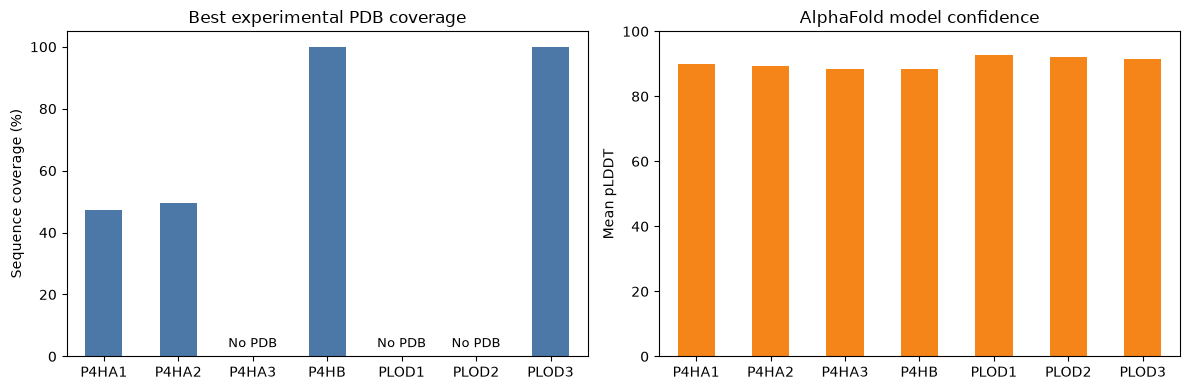

In [47]:

import matplotlib.pyplot as plt
import pandas as pd

gene_order =[
    "P4HA1", "P4HA2", "P4HA3", "P4HB",
    "PLOD1", "PLOD2", "PLOD3"
]

plot_df = (
    structure_summary_df
    .set_index("gene_symbol")
    .loc[gene_order]
    .reset_index()
)
coverage_col = next(
    column for column in plot_df.columns
    if "coverage" in column.lower()
)

plot_df = plot_df.merge(
    alphafold_df[["uniprot_id", "mean_plddt"]],
    on="uniprot_id",
    how="left",
    validate="one_to_one"
)

plddt_col = next(
    column for column in plot_df.columns
    if "plddt" in column.lower()
)


fig, axes = plt.subplots(1,2, figsize =(12, 4))

plot_df.plot.bar(
    x="gene_symbol",
    y=coverage_col,
    ax=axes[0],
    color="#4C78A8",
    legend=False,
    rot=0
)

axes[0].set_title("Best experimental PDB coverage")
axes[0].set_ylabel("Sequence coverage (%)")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 105)

for i, value in enumerate(
    plot_df[coverage_col]
):
    if pd.isna(value):
        axes[0].text(i, 3, "No PDB", ha="center", fontsize=9)

plot_df.plot.bar(
    x="gene_symbol",
    y=plddt_col,
    ax=axes[1],
    color="#F58518",
    legend=False,
    rot=0
)

axes[1].set_title("AlphaFold model confidence")
axes[1].set_ylabel("Mean pLDDT")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 100)

plt.tight_layout()

fig.savefig(
    "Structura_evidence_comparison.png",
    dpi=300
)
plt.show()